# SR250 UWB (Ultra-Wide Band) Radar Visualisation and Digital Beamforming
# Comprehensive Notebook

In this notebook, we are going to extract the data from a dataset containing .npy files, which are the dataset collection of an UWB (Ultra-Wide Band) Radar, apply beamforming and then doing object detection.

## 1. Import required libraries
All necessary libraries from the original notebooks are imported here.

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from PIL import Image
import matplotlib.patches as patches
from typing import Optional, List, Tuple
import json
import random
import gc # Garbage Collection
from typing import Optional

## 2. Global Radar Parameters
These parameters define the physical characteristics of the UWB radar system. They are consistent across all processing tasks.

In [2]:
# --- Radar Parameters ---
d = 1.75e-2          # Distance between rx antenna elements for azimuth (m)
f = 7.987e9          # Center frequency of radar pulse (Hz) -> 7.737 - 8.237 GHz
c = 299792458        # Speed of light (m/s)

l = c / f            # Wavelength (m)
k = 2 * np.pi / l    # Wavenumber (rad/m)

# General beam steering angles range (num_angles will vary per task)
min_angle_deg = -45
max_angle_deg = 45

## 3. Decluttering

### 3.1 Decluttering with Simple Moving Average

The function `decluttering_ma` implements a **Simple Moving Average** (SMA) for background estimation, as described in the Repole's thesis. This is a **Finite Impulse Response (FIR) filter**, meaning its current output only depends on a fixed, finite number of recent past inputs (defined by W).

Formula: $\tilde{s}_{n,m}[k] = s_{n,m}[k] - \frac{1}{W} * \sum_{i = m-W+1}^{m}(s_{n,i}[k]) $

The output for the first $W-1$ frames is set to zero because a full W-sized window is not yet available to compute the average background. For each frame $m$ (starting from W-1), it calculates the average of the current frame and the preceding W-1 frames.

W is the window size: it defines the exact number of frames (current + W-1 previous) that are averaged to form the background estimate for that specific point in time.
The decluttered output for the current frame is calculated subtracting the current radar frame `cirs[m, :]` from the window_average.

**Characteristics**:
* *Fixed Window*: The background estimate is always based on a precise, fixed number of the most recent frames.
* *Abrupt Adaptation*: If a new static object enters the scene, it will cause a strong "ghost" signal for exactly W frames, after which it will be fully incorporated into the background average and suppressed. Similarly, if an object leaves, it will "ghost" for W frames.
* *Memory*: Requires access to (or storage of) the W most recent frames.
* *Risk of Target Suppression*: If a target moves very slowly or stops for a duration longer than W frames, it will be included in the window_average and thus suppressed.


In [3]:
def decluttering_ma(cirs: np.ndarray, W: int) -> np.ndarray:
    """
    Performs decluttering on the time series of CIRs using a moving average
    background subtraction method, as described in Equation (9) of the thesis.

    The decluttered signal s_hat_n,m[k] is calculated as:
    s_hat_n,m[k] = s_n,m[k] - (1/W) * sum(s_n,i[k] for i from m-W+1 to m)

    Args:
        cirs (np.ndarray): Input radar data matrix of shape (time_frames, range_bins),
                           containing complex data.
        W (int): The window dimension (number of subsequent radar frames)
                 to be considered for the moving average. W must be >= 1.

    Returns:
        np.ndarray: The decluttered radar data matrix of the same shape as cirs,
                    containing complex data. The first (W-1) frames will be zeros.
    """
    if cirs.shape[0] == 0:
        return cirs
    
    if not isinstance(W, int) or W < 1:
        raise ValueError("Window size 'W' must be an integer and W >= 1.")

    num_frames, num_range_bins = cirs.shape
    result = np.zeros_like(cirs, dtype=np.complex64)

    # Loop from the (W-1)-th frame (0-indexed) onwards,
    # as this is the first frame for which a full 'W'-sized window is available.
    for m in range(W - 1, num_frames):
        # Define the window: from (m - W + 1) up to and including m
        window_average = np.mean(cirs[m - W + 1 : m + 1, :], axis=0)
        
        # Apply the subtraction formula: current_frame - window_average
        result[m, :] = cirs[m, :] - window_average
        
    return result

### 3.2 Decluttering with Exponential Moving Average

The function `decluttering_ewma` implements an **Exponential Moving Average (EWMA)** for background estimation. It's an **Infinite Impulse Response (IIR) filter**, meaning its current output depends on all past inputs, though older inputs have exponentially decreasing influence.

In the initialization, the *dec_base* (background estimate) is initialized with the very first radar frame (`cirs[0, :]`). The output for the first frame is set to zero.

For each subsequent frame i, the dec_base is updated using the formula:
`dec_base = dec_base * alpha + cirs[i, :] * (1 - alpha)`

alpha is the "forgetting factor" or "smoothing factor." A high alpha means the dec_base retains a large percentage (alpha) of its previous value and incorporates a small percentage (1 - alpha) of the current frame. This makes the background estimate adapt slowly to changes but remain very stable for static clutter.

The decluttered output for the current frame is calculated as:
`result[i, :] = (cirs[i, :] - dec_base) * normalization`
The current radar frame `cirs[i, :]` is subtracted from the continuously updated dec_base. Static clutter, being present in both, will largely cancel out. Moving targets, being absent from dec_base, will remain.

**normalization** is a scaling factor applied to match a specific output scale (as per the original logger's logic).

**Characteristics**:
* *Adaptive*: The background estimate continuously adapts to changes.
* *Smooth Adaptation*: Changes in the background are incorporated smoothly and exponentially.
* *Memory Efficient*: Only needs to store the previous dec_base, not a buffer of past frames.
* *Good for Stable Clutter*: Very effective for suppressing truly static and consistent clutter over long periods.
* *"Ghosting"*: If a new static object appears, it will create a "ghost" signal for a while until it is slowly absorbed into the dec_base. The duration of this ghosting depends on alpha.

In [4]:
def decluttering_ewma (cirs: np.ndarray, alpha: float = 0.9) -> np.ndarray:
    """
    Performs decluttering on the time series of CIRs using Exponential Moving Average.
    Matches the logic of decluttering_alt in the Logger class from original context.

    Args:
        cirs (np.ndarray): Input radar data matrix of shape (time_frames, range_bins),
                           containing complex data.
        alpha (float): The smoothing factor (0 to 1). Higher alpha means slower adaptation.

    Returns:
        np.ndarray: The decluttered radar data matrix of the same shape as cirs,
                    containing complex data. The first frame's output is zeros.
    """
    if cirs.shape[0] == 0:
        return cirs
        
    # 1. Initialise the background (`dec_base`) with the data from the FIRST frame.
    dec_base = cirs[0, :].astype(np.complex64)
    
    # 2. Create an empty result matrix.
    result = np.zeros_like(cirs, dtype=np.complex64)
    
    # 3. The first frame's output is always zero, as per logger.py's logic.
    normalization = (1 + alpha) / 2

    # 4. Loop from the SECOND frame (index 1) onwards.
    for i in range(1, cirs.shape[0]):
        # Calculate the output using the background from the *previous* step
        result[i, :] = (cirs[i, :] - dec_base) * normalization
        
        # Update the background for the *next* iteration
        dec_base = dec_base * alpha + cirs[i, :] * (1 - alpha)
        
    return result

4. Helper Functions for Radar Data Processing
This section contains helper functions for loading, preprocessing, and beamforming radar data.
4.1 Load and Declutter Single Antenna File (Internal Helper)
This helper function loads a single .npy file, applies the specified decluttering method, and is used internally by _get_all_decluttered_complex_data.

In [5]:
def _load_and_declutter_single_file(
    filename: str
) -> Optional[np.ndarray]:
    """
    Loads and declutters a single SR250 antenna file using a specified method.

    Args:
        filename (str): The full path to the .npy file.
        declutter_method (str): 'ma' for Moving Average or 'ewma' for Exponential Moving Average.
        declutter_param (float): 'W' (window size) for 'ma', or 'alpha' (smoothing factor) for 'ewma'.

    Returns:
        np.ndarray: The decluttered radar data matrix (complex data), or None if file not found.
    """
    if not os.path.exists(filename):
        print(f"Warning: File not found, skipping: {filename}")
        return None

    raw_frames = np.load(filename)  # (time, range_bins)
    # raw_frames = raw_frames[:, :50] # Keep only the first 50 bins

    decluttered_matrix = decluttering_ma(raw_frames, 20)
    decluttered_matrix = decluttering_ewma(decluttered_matrix, alpha=0.9)

    # if declutter_method == 'ma':
    #    decluttered_matrix = decluttering_ma(raw_frames, int(declutter_param))
    # elif declutter_method == 'ewma':
    #    decluttered_matrix = decluttering_ewma(raw_frames, alpha=declutter_param)
    # else:
    #    raise ValueError(f"Unknown decluttering method: {declutter_method}")
    
    return decluttered_matrix

4.2 Get All Decluttered Complex Data for Antennas
This function orchestrates the loading and decluttering for all three radar antennas (RX0, RX1, RX2) for a given base filename. It also handles the removal of initial stabilization frames and optionally displays a time-distance plot.
Refactoring Note: This function replaces the visualise_sr250 function from the original notebooks, providing more flexibility in decluttering parameters and separating the time-distance plot display.

In [6]:
def _get_all_decluttered_complex_data(
    base_filename: str,
    stabilization_frames_to_remove: int,
    display_time_distance_plot: bool = False
) -> List[np.ndarray]:
    """
    Loads and declutters SR250 data from antennas RX0 and RX2
    Removes initial stabilization frames. Optionally displays a mean time-distance plot.

    Args:
        base_filename (str): The full path to the '_sr250_rx0.npy' file (used to infer RX1, RX2 paths).
        declutter_method (str): 'ma' for Moving Average or 'ewma' for Exponential Moving Average.
        declutter_param (float): 'W' (window size) for 'ma', or 'alpha' (smoothing factor) for 'ewma'.
        stabilization_frames_to_remove (int): Number of initial frames to remove after decluttering.
        display_time_distance_plot (bool): If True, computes and displays a mean time-distance plot.

    Returns:
        List[np.ndarray]: A list of decluttered complex data matrices, one for each antenna.
                          Returns an empty list if processing fails.
    """
    file_list = []
    if "_sr250_rx0" in base_filename:
        base_path = base_filename.replace("_sr250_rx0.npy", "")
        file_list.append(f"{base_path}_sr250_rx0.npy")
        file_list.append(f"{base_path}_sr250_rx2.npy")
    else:
        print("Error: Please provide the path to an 'sr250_rx0' file.")
        return []

    all_decluttered_complex = []
    all_magnitudes_for_plot = []

    print(f"Processing antenna files for '{os.path.basename(base_filename)}'...")
    for f in file_list:
        decluttered_result = _load_and_declutter_single_file(f)
        if decluttered_result is not None:
            # Remove stabilization frames AFTER decluttering
            final_decluttered_data = decluttered_result[stabilization_frames_to_remove:, :]
            all_decluttered_complex.append(final_decluttered_data)
            if display_time_distance_plot:
                all_magnitudes_for_plot.append(np.abs(final_decluttered_data))
            print(f"  {os.path.basename(f)} processed. Shape after decluttering and frame removal: {final_decluttered_data.shape}")
        else:
            print(f"  Skipping {f} due to loading/decluttering issue.")

    if not all_decluttered_complex:
        print("Error: No data was processed for any antenna. Returning empty list.")
        return []

    if display_time_distance_plot:
        if all_magnitudes_for_plot:
            combined_magnitude_matrix = np.mean(np.stack(all_magnitudes_for_plot, axis=0), axis=0)
            show_time_distance_plot(combined_magnitude_matrix, f"SR250 UWB Time-Distance Heatmap - Mean of All Antennas ({os.path.basename(base_filename).replace('_sr250_rx0.npy', '')})")
        else:
            print("  No magnitude data available to display time-distance plot.")

    return all_decluttered_complex

### 4.3 Compute Beamforming Weights
Calculates the complex weights required for digital beamforming, based on the array geometry and desired steering angles.

In [7]:
def compute_bf_weights(angle_range_rad: np.ndarray, delta: float, k_wavenumber: float, num_rx_elements: int) -> np.ndarray:
    """
    Computes beamforming weights for a linear array.
    
    Args:
        angle_range_rad (np.ndarray): Array of angles (in radians) for which to compute weights.
        delta (float): Distance between adjacent antenna elements.
        k_wavenumber (float): Wavenumber (2*pi/lambda).
        num_rx_elements (int): Number of receive antenna elements.
        
    Returns:
        np.ndarray: Beamforming weights of shape (len(angle_range_rad), num_rx_elements).
    """
    bf_weights = np.zeros((angle_range_rad.shape[0], num_rx_elements), dtype="complex")
    for i in range(angle_range_rad.shape[0]):      # Loop over angles
        for j in range(num_rx_elements):       # Loop over antenna elements
            # Phase shift for element j at angle_range_rad[i]
            bf_weights[i, j] = np.exp(-1j * k_wavenumber * delta * j * np.sin(angle_range_rad[i]))
    return bf_weights

### 4.4 Perform Azimuth Beamforming
Applies the computed beamforming weights to the complex radar data from two antennas (RX0 and RX2) to produce a Range-Azimuth map over time.

In [8]:
def perform_azimuth_beamforming(
    rx0_complex_data: np.ndarray,
    rx1_complex_data: np.ndarray, 
    d_spacing: float,
    k_wavenumber: float,
    beam_steering_angles_rad: np.ndarray
) -> Optional[np.ndarray]:
    """
    Performs azimuth beamforming on complex data from two antennas.
    This version processes all time frames individually, producing a 3D output.
    The input `rx1_complex_data` is intended to be the data from the second antenna used
    for beamforming (e.g., RX2 when RX0 is the first).

    Args:
        rx0_complex_data (np.ndarray): Complex CIRs from the first antenna (time_frames, range_bins).
        rx1_complex_data (np.ndarray): Complex CIRs from the second antenna (time_frames, range_bins).
        d_spacing (float): Distance between the two RX antennas (element spacing).
        k_wavenumber (float): Wavenumber (2*pi/lambda).
        beam_steering_angles_rad (np.ndarray): Array of angles in radians for beamsteering.

    Returns:
        np.ndarray: Beamformed data of shape (time_frames, range_bins, angles), or None if error.
    """
    # Resize the range bins due to slight mismatch, as observed in original notebooks
    # This assumes rx0 is the "reference" and rx1 is the "second" antenna (e.g. RX2 from file_list)
    rx0_cropped = rx0_complex_data[:, 0:45]
    rx1_cropped = rx1_complex_data[:, 2:47] # Shifted by 2 bins relative to rx0_cropped

    if rx0_cropped is None or rx1_cropped is None:
        print("Error: Input data for beamforming is missing.")
        return None
    if rx0_cropped.shape != rx1_cropped.shape:
        print(f"Error: Antenna data shapes do not match after cropping: {rx0_cropped.shape} vs {rx1_cropped.shape}. Cannot perform beamforming.")
        return None
    else:
        print(f"Shape of the antennas data after cropping: {rx0_cropped.shape}, with dtype {rx0_cropped.dtype}")
    
    num_time_frames = rx0_cropped.shape[0]   # Slow time
    num_range_bins = rx0_cropped.shape[1]    # Fast time
    num_rx_elements = 2 # Always 2 antennas for azimuth beamforming
    num_angles = beam_steering_angles_rad.shape[0]

    # Compute beamforming weights. These are constant for all time frames and range bins.
    bf_weights = compute_bf_weights(beam_steering_angles_rad, d_spacing, k_wavenumber, num_rx_elements)

    # Initialize a 3D array to store beamformed results
    beamformed_3d_result = np.zeros((num_time_frames, num_range_bins, num_angles), dtype=complex)
    print(f"Starting beamforming over {num_time_frames} time frames and {num_range_bins} range bins...")

    # This version exploits NumPy vectorized operations for efficiency.
    for t in range(num_time_frames):
        # Stack complex CIRs for the current time frame from both RX antennas
        # data_for_current_frame_all_bins will have shape (num_rx_elements, range_bins)
        data_for_current_frame_all_bins = np.stack([rx0_cropped[t, :], rx1_cropped[t, :]], axis=0) # [2], [4]

        # Perform matrix multiplication for all range bins in the current frame simultaneously
        # (num_angles, num_rx_elements) @ (num_rx_elements, num_range_bins)
        # Result of dot product: (num_angles, num_range_bins)
        beamformed_slice_transposed = np.dot(bf_weights, data_for_current_frame_all_bins)
        
        # Transpose the result to get (range_bins, angles) for this time slice
        beamformed_3d_result[t, :, :] = beamformed_slice_transposed.T
            
    print("Beamforming complete for all frames and range bins.")
    return beamformed_3d_result

### 4.5 Normalize Range-Angle Map
Normalizes a 2D Range-Angle map to the range [1] using min-max scaling, as described in Equation (11) of the thesis.

In [9]:
def normalize_range_angle_map(matrix: np.ndarray) -> np.ndarray:
    """
    Normalizes a 2D Range-Angle map to the range [0, 1] using min-max scaling.

    Args:
        matrix (np.ndarray): The input 2D Range-Angle map.

    Returns:
        np.ndarray: The normalized map.
    """
    min_val = np.min(matrix)
    max_val = np.max(matrix)
    if max_val == min_val: # Avoid division by zero for uniform matrices
        return np.zeros_like(matrix)
    normalized_matrix = (matrix - min_val) / (max_val - min_val)
    return normalized_matrix

### 4.6 Show Time-Distance Plot
Visualizes the magnitude of radar data over time and distance as a heatmap.

In [10]:
def show_time_distance_plot(matrix: np.ndarray, title: str = "SR250 UWB Time-Distance Heatmap"):
    """
    Visualizes the time-distance (heatmap) of radar data magnitude.

    Args:
        matrix (np.ndarray): The input matrix (time_frames, range_bins).
        title (str): Title for the plot.
    """
    # The matrix shape is already (time, distance). We need to transpose for plotting
    # so that distance is on Y-axis and time on X-axis.
    heatmap_data = matrix.T

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(
        heatmap_data, 
        aspect='auto', 
        origin='lower', # Origin lower for distance on Y-axis (0 at bottom)
        cmap='gist_gray',
        interpolation='nearest',
        vmin=np.min(heatmap_data),
        vmax=np.percentile(heatmap_data, 99) # Use 99th percentile for better contrast
    )

    ax.set_title(title)
    ax.set_xlabel("Time (Frame Number)")
    ax.set_ylabel("Distance (Range Bin)")
    fig.colorbar(im, ax=ax, label="Average Signal Magnitude")
    
    plt.tight_layout()
    plt.show()
    plt.close(fig) # Close the figure to free up memory

### 4.7 Plot Range-Angle Heatmap (Flexible Helper)
A flexible plotting function for beamformed Range-Azimuth maps. It can save to a file, display on screen, and highlight ground truth positions.
Refactoring Note: This function replaces show_range_angle_plot from the original notebooks, combining their functionalities and adding more control.

In [11]:
def _plot_range_angle_heatmap(
    matrix: np.ndarray,
    angles_rad: np.ndarray,
    title: str = "Beamformed Range-Azimuth Image",
    range_conversion_factor: int = 10,
    output_dir: Optional[str] = None, # If provided, saves to this directory
    show_plot: bool = True, # If True, calls plt.show()
    gt_highlight_coords_list: Optional[List[Tuple[int, int]]] = None,
    image_width_px: Optional[int] = None, # For OD dataset specific saved image width
    image_height_px: Optional[int] = None # For OD dataset specific saved image height
) -> Optional[str]:
    """
    Visualizes the beamformed data as a 2D heatmap (Distance vs. Azimuth Angle).
    Converts range bins to meters for visualization.
    Optionally draws cross markers at specified ground truth positions.
    Can save the image to a file and/or display it.

    Args:
        matrix (np.ndarray): The beamformed data, shape (range_bins, angles).
                             This should be the magnitude for plotting.
        angles_rad (np.ndarray): Array of angles in radians used for beamsteering.
        title (str): Title for the plot.
        range_conversion_factor (int/float): Number of bins per meter.
        output_dir (Optional[str]): Directory to save the image. If None, image is not saved.
        show_plot (bool): If True, displays the plot using plt.show().
        gt_highlight_coords_list (Optional[List[Tuple[int, int]]]): A list of (range_bin_idx, angle_idx) tuples
                                                           to draw cross markers on the heatmap.
        image_width_px (Optional[int]): Target width in pixels for saved image.
        image_height_px (Optional[int]): Target height in pixels for saved image.

    Returns:
        Optional[str]: The filename of the saved image if `output_dir` is provided, otherwise None.
    """
    
    print("Generating Beamformed plot...")

    heatmap_data = matrix
    
    # Calculate figsize to match target pixel dimensions if provided for saving.
    # Otherwise, use a default display size.
    dpi_for_save = 100 # Consistent DPI for saving
    if output_dir and image_width_px and image_height_px:
        # figsize = pixels / dpi
        fig, ax = plt.subplots(figsize=(2, 2))
    else:
        fig, ax = plt.subplots(figsize=(12, 5)) # Default size for display
    
    angles_deg = np.rad2deg(angles_rad)

    min_range_meters = 0
    max_range_meters = heatmap_data.shape[0] / range_conversion_factor

    extent = [angles_deg.min(), angles_deg.max(), min_range_meters, max_range_meters] 

    im = ax.imshow(
        heatmap_data, 
        aspect='auto', 
        origin='lower', 
        cmap='gist_gray',
        interpolation='nearest',
        vmin=np.min(heatmap_data),
        vmax=np.max(heatmap_data),
        extent=extent 
    )
    
    # --- Add cross markers for ground truth positions if provided ---
    if gt_highlight_coords_list:
        for i, (r_idx, a_idx) in enumerate(gt_highlight_coords_list):
            # Convert range_bin_idx to meters and angle_idx to degrees for plotting
            plot_y_meters = r_idx / range_conversion_factor
            plot_x_degrees = np.rad2deg(angles_rad[a_idx])
            label_text = 'Ground Truth Position' if i == 0 else None
            ax.scatter(plot_x_degrees, plot_y_meters, marker='x', color='red', s=200, linewidth=3, label=label_text)
        if gt_highlight_coords_list:
            ax.legend()
    
    saved_filename = None
    if output_dir:
        image_filename = f"{title}.png"
        full_output_path = os.path.join(output_dir, image_filename)
        os.makedirs(output_dir, exist_ok=True) # Ensure the directory exists
        
        # Turn off axes for clean image saving if specific pixel dimensions are requested
        if image_width_px and image_height_px:
             ax.axis('off')
             try:
                 fig.savefig(full_output_path, bbox_inches='tight', pad_inches=0, dpi=dpi_for_save)
                 print(f"Image saved successfully to: {full_output_path}")
                 saved_filename = image_filename
             except Exception as e:
                 print(f"Error saving image to {full_output_path}: {e}")
        else: # For general saving without specific pixel constraints, keep axes on
            try:
                fig.savefig(full_output_path, bbox_inches='tight', dpi=dpi_for_save)
                print(f"Image saved successfully to: {full_output_path}")
                saved_filename = image_filename
            except Exception as e:
                print(f"Error saving image to {full_output_path}: {e}")
    
    if show_plot:
        ax.axis('on') # Ensure axes are on if showing, even if turned off for saving
        ax.set_title(title)
        ax.set_xlabel("Azimuth Angle (degrees)")
        ax.set_ylabel("Distance (meters)")
        fig.colorbar(im, ax=ax, label="Beamformed Signal Magnitude")
        
        num_ticks_x = 7 
        tick_indices_x = np.linspace(0, len(angles_deg) - 1, num_ticks_x).astype(int)
        ax.set_xticks(angles_deg[tick_indices_x])
        ax.set_xticklabels([f"{a:.0f}°" for a in angles_deg[tick_indices_x]])

        if max_range_meters <= 1:
            y_tick_interval = 0.1
        elif max_range_meters <= 5:
            y_tick_interval = 0.5
        else:
            y_tick_interval = 1.0
        
        y_ticks = np.arange(min_range_meters, max_range_meters + y_tick_interval, y_tick_interval)
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([f"{d:.1f}m" for d in y_ticks])
        
        plt.tight_layout()
        plt.show()
    
    plt.close(fig) # Always close the figure to free up memory
    return saved_filename

## 5. General Visualization Tasks
This section focuses on loading, processing, and visualizing radar data, including time-distance plots and a single aggregated Range-Azimuth beamformed image. This mirrors the primary goal of sr250-visualisation-and-dbf.ipynb.

In [12]:
def run_visualization_pipeline(
    base_file: str,
    stabilization_frames: int = 20,
    num_angles: int = 31,
    vis_time_window_frames: int = 40 # Total frames for visualization (e.g., 2 seconds of data)
):
    """
    Orchestrates the visualization pipeline: loads, declutters, beamforms,
    and displays time-distance and range-angle plots for a single radar file.

    Args:
        base_file (str): Path to the '_sr250_rx0.npy' file.
        stabilization_frames (int): Number of initial frames to remove after decluttering.
        num_angles (int): Number of azimuth angles to consider for beamforming.
        averaging_mode (int): 0 for coherent, 1 for incoherent sum, 2 for incoherent mean averaging
                              over the visualization time window.
        vis_time_window_frames (int): Number of time frames to aggregate for the final Range-Azimuth plot.
    """
    print(f"\n--- Running Visualization Pipeline for: {os.path.basename(base_file)} ---")
    
    # Generate beam steering angles for visualization
    beam_steering_angles_vis = np.deg2rad(np.linspace(min_angle_deg, max_angle_deg, num_angles))

    # 1. Load and declutter data for all antennas, and optionally show time-distance plot
    all_complex_data = _get_all_decluttered_complex_data(
        base_file,
        stabilization_frames_to_remove=stabilization_frames,
        display_time_distance_plot=True # Display the time-distance plot for this task
    )

    if not all_complex_data:
        print(f"Error: Not enough complex data")
        return

    antenna1_data = all_complex_data[0] # RX0
    antenna2_data = all_complex_data[1] # RX2

    # 2. Perform azimuth beamforming
    print(f"Performing azimuth beamforming using RX0 and RX2 data...")
    beamformed_3d_data = perform_azimuth_beamforming(
        antenna1_data, antenna2_data, d, k, beam_steering_angles_vis
    )
    
    if beamformed_3d_data is None:
        print("Beamforming failed for visualization pipeline.")
        return

    # 3. Aggregate 3D data for 2D Range-Azimuth visualization
    actual_vis_end_frame = min(vis_time_window_frames, beamformed_3d_data.shape[0])
    
    if actual_vis_end_frame == 0:
        print("Not enough frames for visualization after processing and trimming.")
        return
        
    print(f"Aggregating {actual_vis_end_frame} frames for Range-Azimuth plot using coherent averaging...")
    aggregated_beamformed_data_vis = np.abs(np.sum(beamformed_3d_data[0:actual_vis_end_frame, :, ], axis=0))
    
    # 4. Normalize and display the Range-Azimuth plot
    normalized_beamformed_data_vis = normalize_range_angle_map(aggregated_beamformed_data_vis)
    title = f"Beamforming ({actual_vis_end_frame} time frames) - {os.path.basename(base_file).replace('_sr250_rx0.npy', '')}"
    _plot_range_angle_heatmap(
        normalized_beamformed_data_vis, beam_steering_angles_vis, title, show_plot=True
    )
    print("--- Visualization Pipeline Complete ---")


--- Running Example 1: Coherent Averaging with MA Decluttering ---

--- Running Visualization Pipeline for: 12_Still position_20250618-112436_sr250_rx0.npy ---
Processing antenna files for '12_Still position_20250618-112436_sr250_rx0.npy'...
  12_Still position_20250618-112436_sr250_rx0.npy processed. Shape after decluttering and frame removal: (1200, 120)
  12_Still position_20250618-112436_sr250_rx2.npy processed. Shape after decluttering and frame removal: (1200, 120)


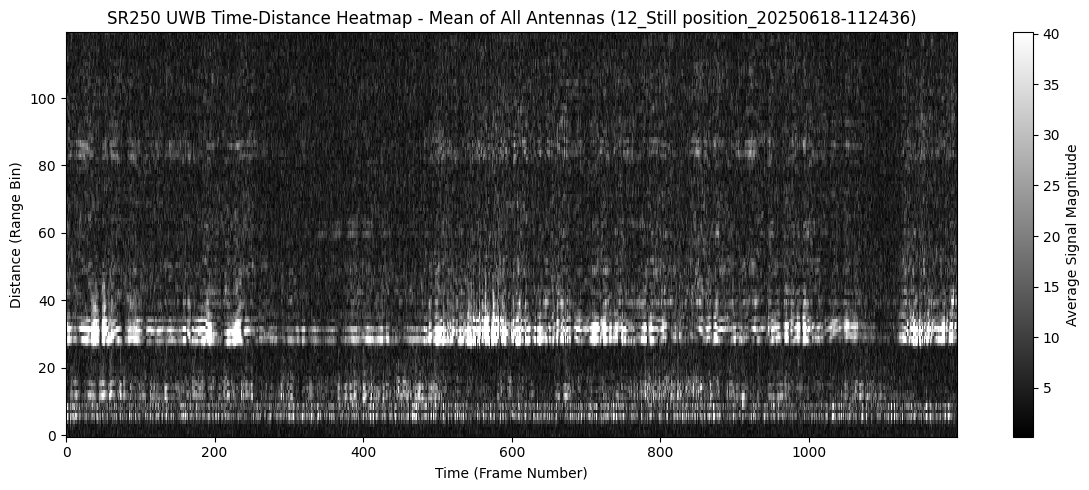

Performing azimuth beamforming using RX0 and RX2 data...
Shape of the antennas data after cropping: (1200, 45), with dtype complex64
Starting beamforming over 1200 time frames and 45 range bins...
Beamforming complete for all frames and range bins.
Aggregating 20 frames for Range-Azimuth plot using coherent averaging...
Generating Beamformed plot...


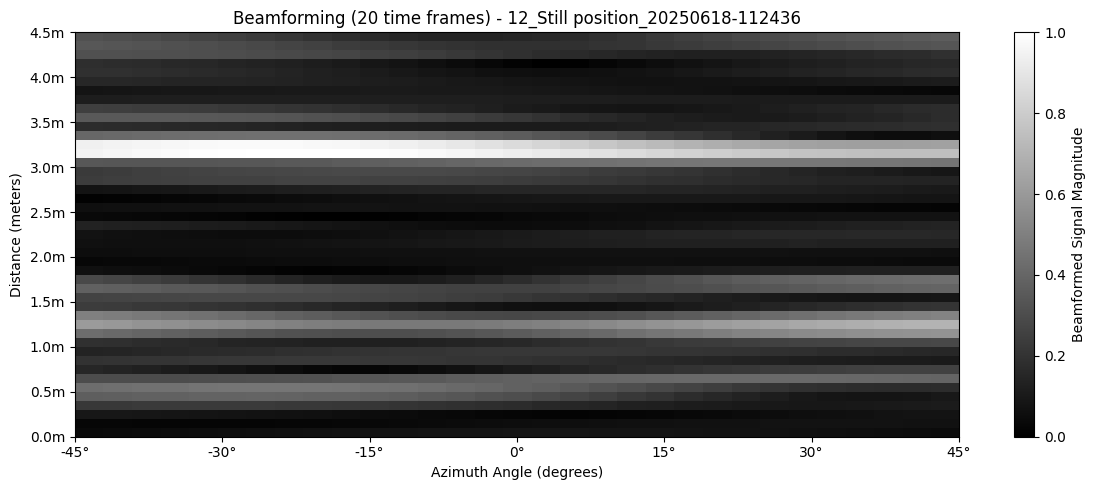

--- Visualization Pipeline Complete ---

--- Running Example 2: Coherent Averaging with EWMA Decluttering ---

--- Running Visualization Pipeline for: 13-12_Still position_20250618-141554_sr250_rx0.npy ---
Processing antenna files for '13-12_Still position_20250618-141554_sr250_rx0.npy'...
  13-12_Still position_20250618-141554_sr250_rx0.npy processed. Shape after decluttering and frame removal: (1200, 120)
  13-12_Still position_20250618-141554_sr250_rx2.npy processed. Shape after decluttering and frame removal: (1200, 120)


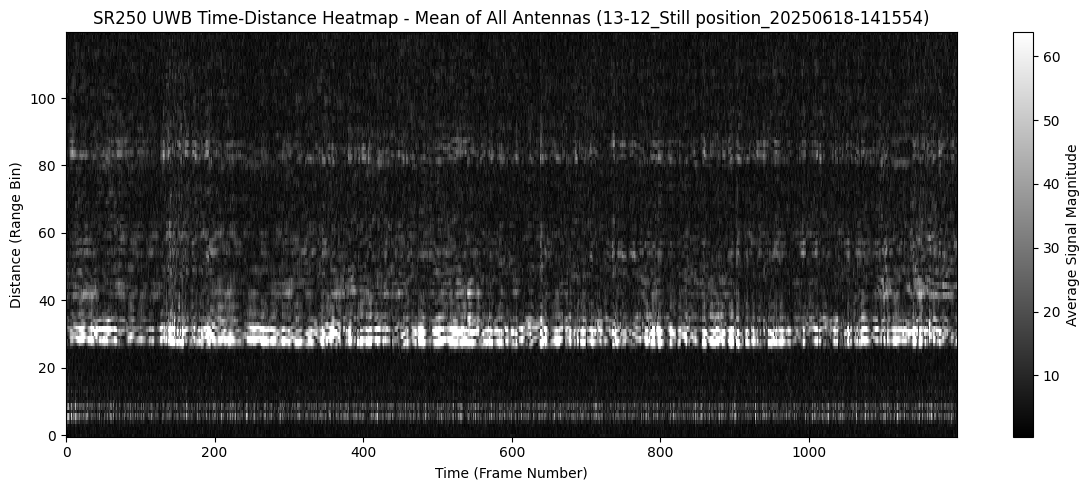

Performing azimuth beamforming using RX0 and RX2 data...
Shape of the antennas data after cropping: (1200, 45), with dtype complex64
Starting beamforming over 1200 time frames and 45 range bins...
Beamforming complete for all frames and range bins.
Aggregating 20 frames for Range-Azimuth plot using coherent averaging...
Generating Beamformed plot...


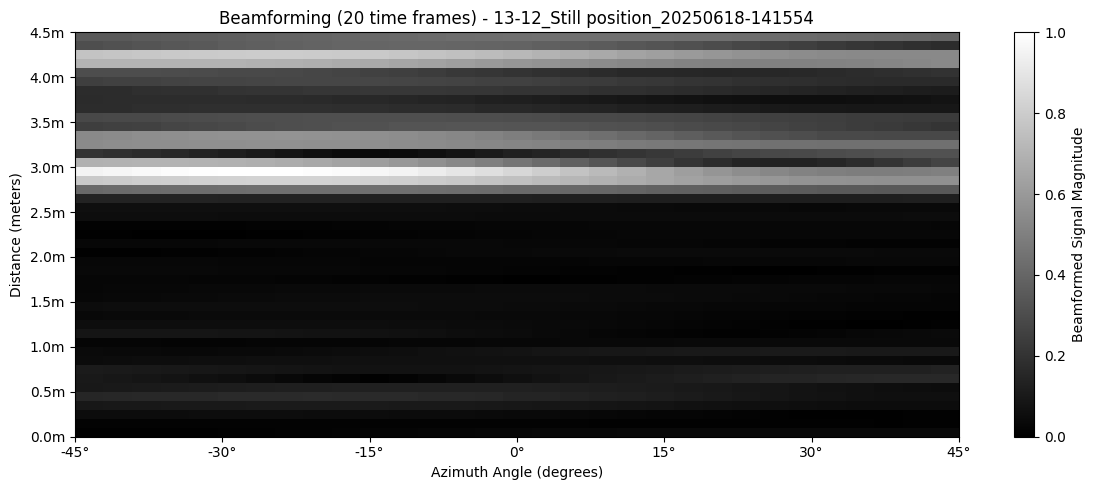

--- Visualization Pipeline Complete ---

--- Running Example 3: Multiple Targets (2-4) with Coherent Averaging and EWMA ---

--- Running Visualization Pipeline for: 2-4_Still position_20250618-140706_sr250_rx0.npy ---
Processing antenna files for '2-4_Still position_20250618-140706_sr250_rx0.npy'...
  2-4_Still position_20250618-140706_sr250_rx0.npy processed. Shape after decluttering and frame removal: (1200, 120)
  2-4_Still position_20250618-140706_sr250_rx2.npy processed. Shape after decluttering and frame removal: (1200, 120)


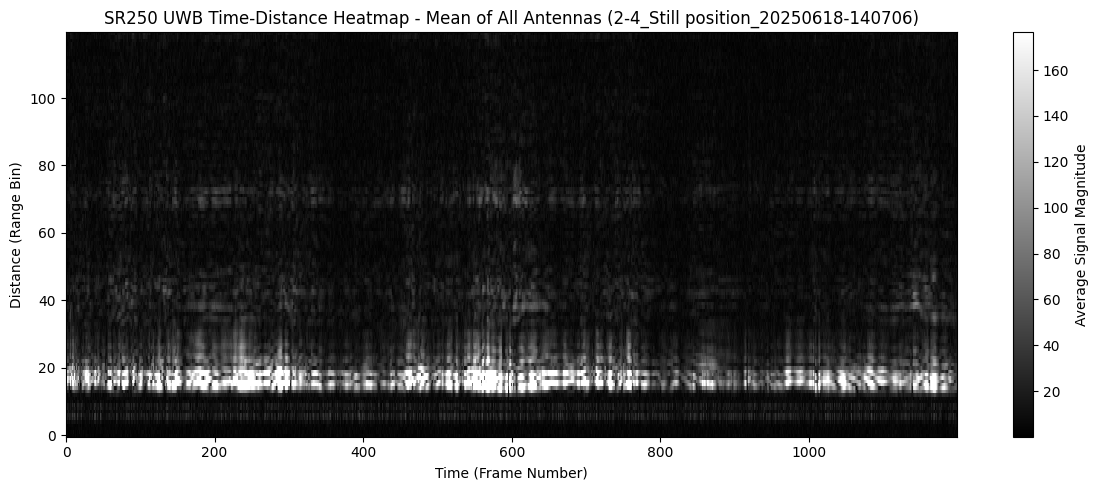

Performing azimuth beamforming using RX0 and RX2 data...
Shape of the antennas data after cropping: (1200, 45), with dtype complex64
Starting beamforming over 1200 time frames and 45 range bins...
Beamforming complete for all frames and range bins.
Aggregating 20 frames for Range-Azimuth plot using coherent averaging...
Generating Beamformed plot...


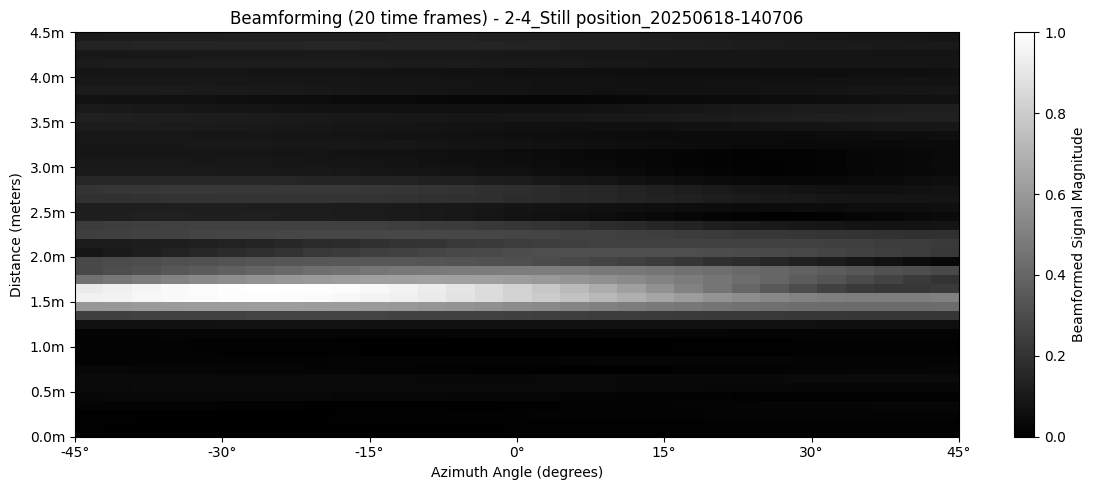

--- Visualization Pipeline Complete ---

--- Running Example 4: Single Target (2) with Coherent Averaging and MA ---

--- Running Visualization Pipeline for: 2_Still position_20250618-110517_sr250_rx0.npy ---
Processing antenna files for '2_Still position_20250618-110517_sr250_rx0.npy'...
  2_Still position_20250618-110517_sr250_rx0.npy processed. Shape after decluttering and frame removal: (1200, 120)
  2_Still position_20250618-110517_sr250_rx2.npy processed. Shape after decluttering and frame removal: (1200, 120)


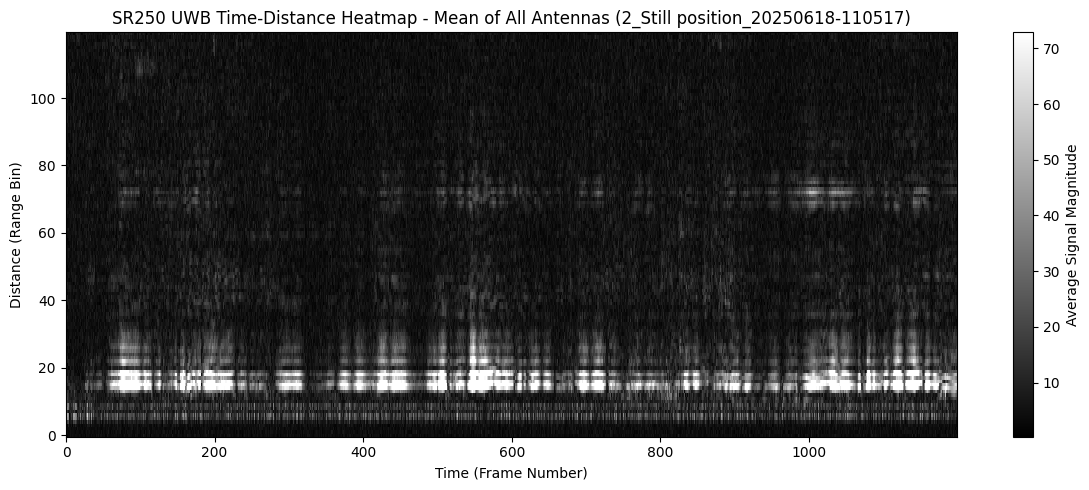

Performing azimuth beamforming using RX0 and RX2 data...
Shape of the antennas data after cropping: (1200, 45), with dtype complex64
Starting beamforming over 1200 time frames and 45 range bins...
Beamforming complete for all frames and range bins.
Aggregating 20 frames for Range-Azimuth plot using coherent averaging...
Generating Beamformed plot...


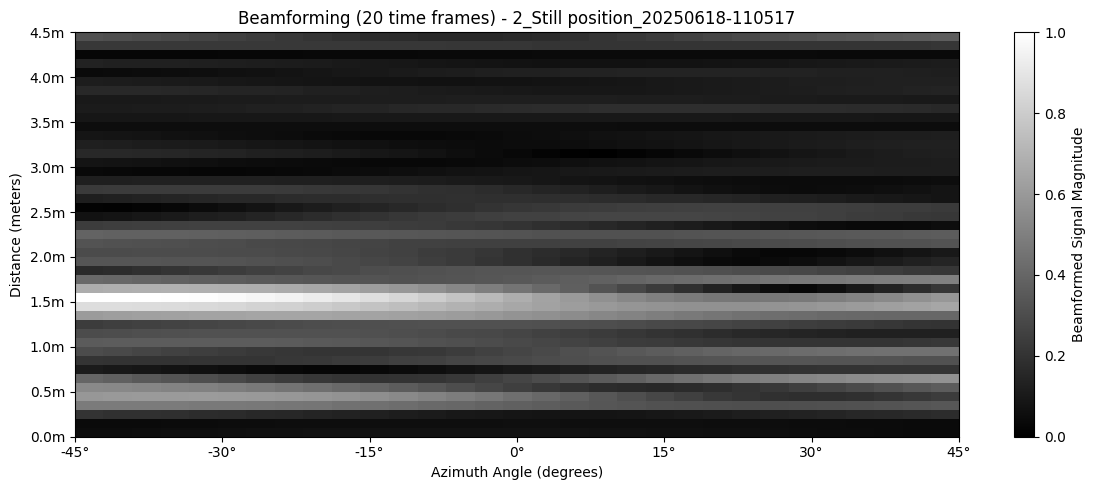

--- Visualization Pipeline Complete ---

--- Running Example 5: Multiple Targets (4-3) with Coherent Averaging and MA ---

--- Running Visualization Pipeline for: 4-3_Still position_20250618-141131_sr250_rx0.npy ---
Processing antenna files for '4-3_Still position_20250618-141131_sr250_rx0.npy'...
  4-3_Still position_20250618-141131_sr250_rx0.npy processed. Shape after decluttering and frame removal: (1200, 120)
  4-3_Still position_20250618-141131_sr250_rx2.npy processed. Shape after decluttering and frame removal: (1200, 120)


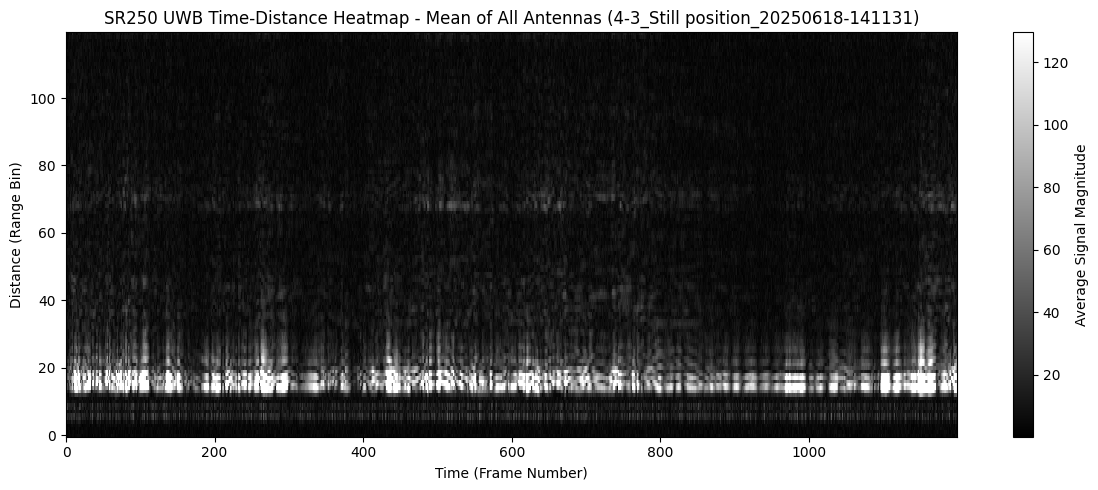

Performing azimuth beamforming using RX0 and RX2 data...
Shape of the antennas data after cropping: (1200, 45), with dtype complex64
Starting beamforming over 1200 time frames and 45 range bins...
Beamforming complete for all frames and range bins.
Aggregating 20 frames for Range-Azimuth plot using coherent averaging...
Generating Beamformed plot...


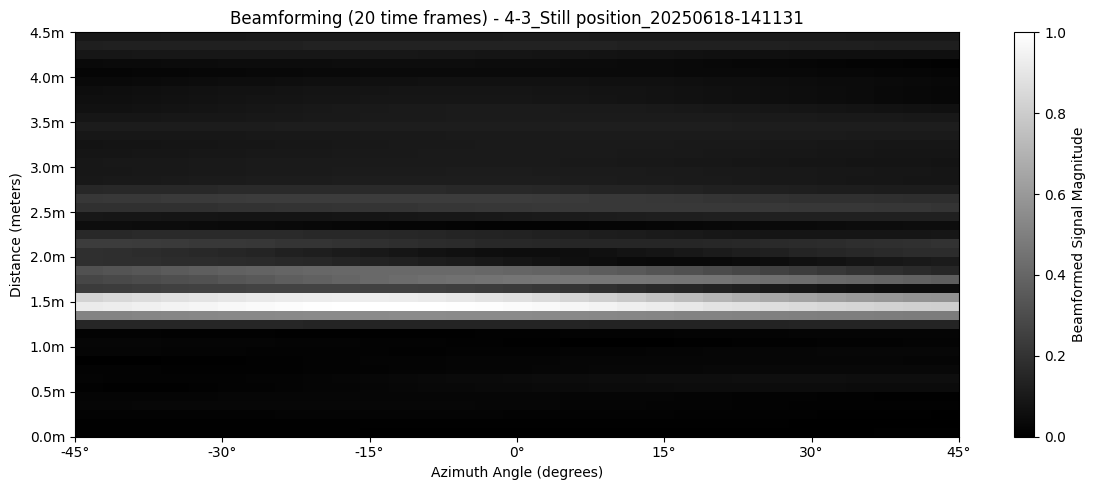

--- Visualization Pipeline Complete ---

--- Running Example 6: Multiple Targets (13-8) with Coherent Averaging and EWMA ---

--- Running Visualization Pipeline for: 13-8_Still position_20250618-142153_sr250_rx0.npy ---
Processing antenna files for '13-8_Still position_20250618-142153_sr250_rx0.npy'...
  13-8_Still position_20250618-142153_sr250_rx0.npy processed. Shape after decluttering and frame removal: (1200, 120)
  13-8_Still position_20250618-142153_sr250_rx2.npy processed. Shape after decluttering and frame removal: (1200, 120)


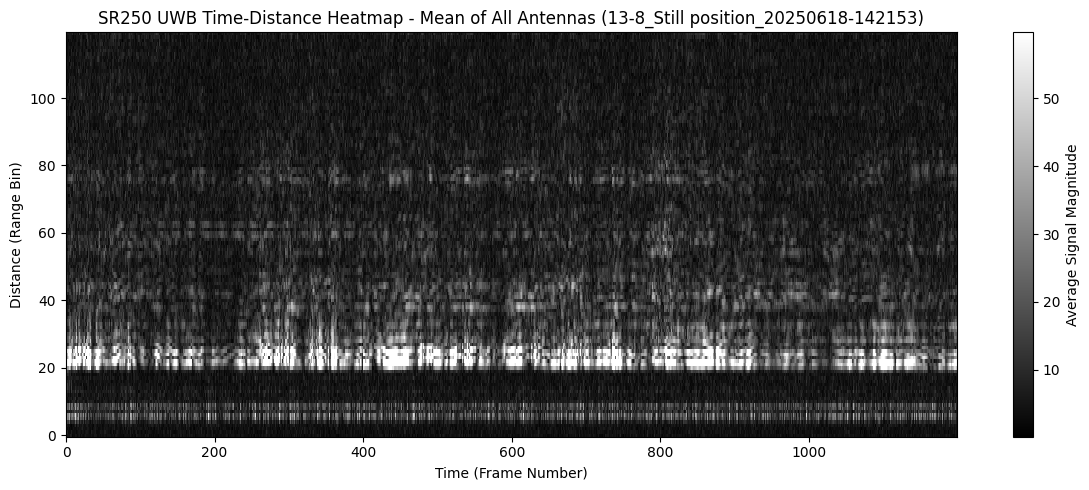

Performing azimuth beamforming using RX0 and RX2 data...
Shape of the antennas data after cropping: (1200, 45), with dtype complex64
Starting beamforming over 1200 time frames and 45 range bins...
Beamforming complete for all frames and range bins.
Aggregating 20 frames for Range-Azimuth plot using coherent averaging...
Generating Beamformed plot...


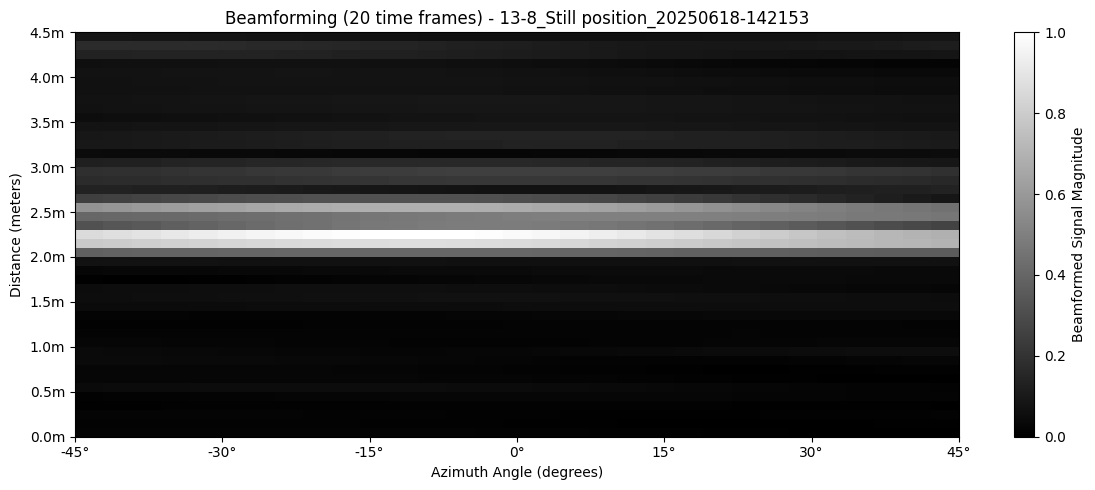

--- Visualization Pipeline Complete ---

--- Running Example 7: Moving targets with Coherent Averaging and MA ---

--- Running Visualization Pipeline for: (move)2-12-9-3-13-14-4-8-13-2_Still position_20250618-152004_sr250_rx0.npy ---
Processing antenna files for '(move)2-12-9-3-13-14-4-8-13-2_Still position_20250618-152004_sr250_rx0.npy'...
  (move)2-12-9-3-13-14-4-8-13-2_Still position_20250618-152004_sr250_rx0.npy processed. Shape after decluttering and frame removal: (6000, 120)
  (move)2-12-9-3-13-14-4-8-13-2_Still position_20250618-152004_sr250_rx2.npy processed. Shape after decluttering and frame removal: (6000, 120)


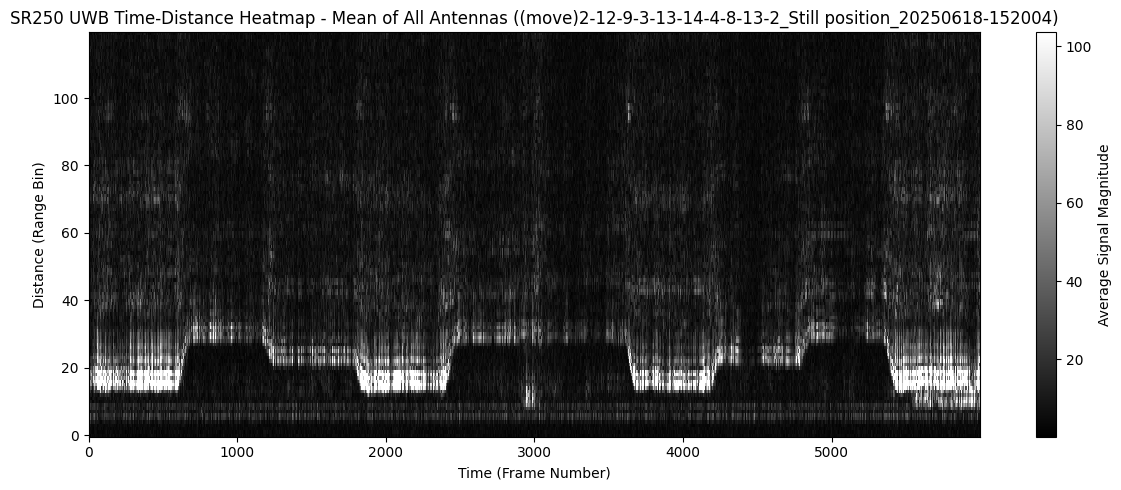

Performing azimuth beamforming using RX0 and RX2 data...
Shape of the antennas data after cropping: (6000, 45), with dtype complex64
Starting beamforming over 6000 time frames and 45 range bins...
Beamforming complete for all frames and range bins.
Aggregating 20 frames for Range-Azimuth plot using coherent averaging...
Generating Beamformed plot...


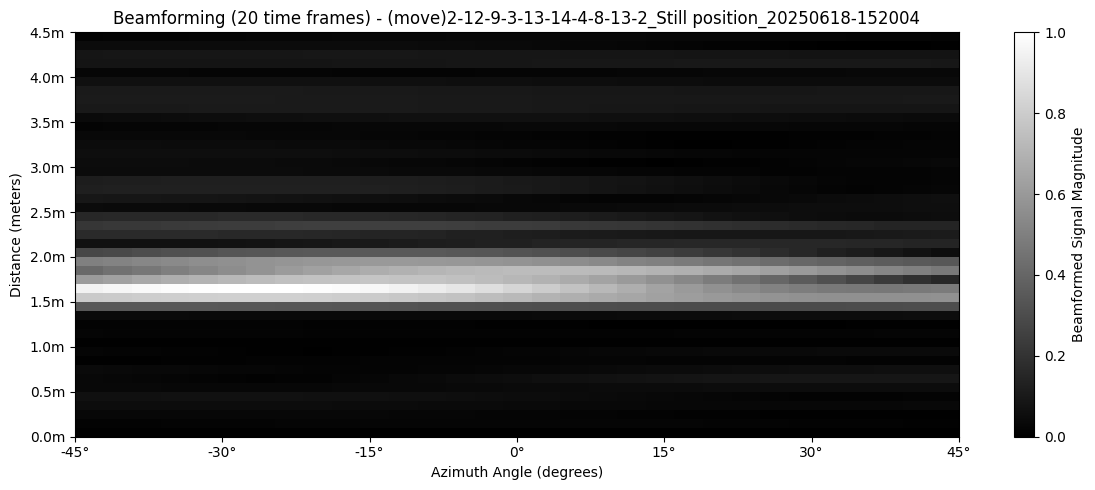

--- Visualization Pipeline Complete ---


In [13]:
# Example 1: Coherent averaging with decluttering_ma (W=20)
print("\n--- Running Example 1: Coherent Averaging with MA Decluttering ---")
base_file_for_vis1 = "/kaggle/input/haeeai-project-uwb/SR250Mate/12_Still position_20250618-112436_sr250_rx0.npy"
run_visualization_pipeline(base_file_for_vis1, stabilization_frames=20, vis_time_window_frames=20)

# Example 2: Coherent averaging with decluttering_ewma (alpha=0.9)
print("\n--- Running Example 2: Coherent Averaging with EWMA Decluttering ---")
base_file_for_vis2 = "/kaggle/input/haeeai-project-uwb/SR250Mate/13-12_Still position_20250618-141554_sr250_rx0.npy"
run_visualization_pipeline(base_file_for_vis2, stabilization_frames=20, vis_time_window_frames=20)

# Example 4: Multiple targets with coherent averaging and EWMA
print("\n--- Running Example 3: Multiple Targets (2-4) with Coherent Averaging and EWMA ---")
base_file_for_vis3 = "/kaggle/input/haeeai-project-uwb/SR250Mate/2-4_Still position_20250618-140706_sr250_rx0.npy"
run_visualization_pipeline(base_file_for_vis3, stabilization_frames=20, vis_time_window_frames=20)

# Example 5: Single target with coherent averaging and MA
print("\n--- Running Example 4: Single Target (2) with Coherent Averaging and MA ---")
base_file_for_vis4 = "/kaggle/input/haeeai-project-uwb/SR250Mate/2_Still position_20250618-110517_sr250_rx0.npy"
run_visualization_pipeline(base_file_for_vis4, stabilization_frames=20, vis_time_window_frames=20)

# Example 6: Multiple targets with coherent averaging and MA
print("\n--- Running Example 5: Multiple Targets (4-3) with Coherent Averaging and MA ---")
base_file_for_vis5 = "/kaggle/input/haeeai-project-uwb/SR250Mate/4-3_Still position_20250618-141131_sr250_rx0.npy"
run_visualization_pipeline(base_file_for_vis5, stabilization_frames=20, vis_time_window_frames=20)

# Example 7: Multiple targets (13-8) with coherent averaging and EWMA
print("\n--- Running Example 6: Multiple Targets (13-8) with Coherent Averaging and EWMA ---")
base_file_for_vis6 = "/kaggle/input/haeeai-project-uwb/SR250Mate/13-8_Still position_20250618-142153_sr250_rx0.npy"
run_visualization_pipeline(base_file_for_vis6, stabilization_frames=20, vis_time_window_frames=20)

# Example 7: Multiple targets (13-8) with coherent averaging and EWMA
print("\n--- Running Example 7: Moving targets with Coherent Averaging and MA ---")
base_file_for_vis7 = "/kaggle/input/haeeai-project-uwb/SR250Mate/(move)2-12-9-3-13-14-4-8-13-2_Still position_20250618-152004_sr250_rx0.npy"
run_visualization_pipeline(base_file_for_vis7, stabilization_frames=20, vis_time_window_frames=20)

## 6. Object Detection Dataset Creation Tasks
This section focuses on generating a dataset for object detection. It processes radar files in sliding time windows, creates range-angle images, and generates corresponding JSON label files with bounding box annotations. This reflects the functionality of sr250-extract-od-dataset.ipynb.

In [14]:
# Constants for image generation and bounding boxes for the object detection task
# These dimensions are derived from the original notebook's figsize=(3,3) and dpi=100
# after tight cropping, resulting in an effective content area of roughly 310x308 pixels.
# The num_angles = 31 in this context also influences the width.
IMAGE_WIDTH = 155
IMAGE_HEIGHT = 154

BB_SIZE = 40 # Bounding box size (BB_SIZE x BB_SIZE) in pixels

MIN_DISTANCE = 0
MAX_DISTANCE = 4.5 # Max distance in meters for the range axis visualization

high_dist = round(((IMAGE_HEIGHT / MAX_DISTANCE) * 1) - BB_SIZE / 2, 1) # Position 1.5 meter from radar
med_dist = round(((IMAGE_HEIGHT / MAX_DISTANCE) * 2) - BB_SIZE / 2, 1)  # Position 2.5 meters from radar
low_dist = round(((IMAGE_HEIGHT / MAX_DISTANCE) * 3) - BB_SIZE / 2, 1)  # Position 3.5 meters from radar

left_angle = round((IMAGE_WIDTH * 0.25) - BB_SIZE / 2, 1)
med_angle = round((IMAGE_WIDTH * 0.5) - BB_SIZE / 2, 1)
right_angle = round((IMAGE_WIDTH * 0.75) - BB_SIZE / 2, 1)

# Define the map (position_label) -> (x_coord, y_coord) for bounding box top-left corner
# The labels (2-14) correspond to specific ground truth positions.
# Example: "2" is right, low distance.
positions_map = {
    "2": (right_angle, low_dist),
    "3": (med_angle, low_dist),
    "4": (left_angle, low_dist),
    "7": (right_angle, med_dist),
    "8": (med_angle, med_dist),
    "9": (left_angle, med_dist),
    "12": (right_angle, high_dist),
    "13": (med_angle, high_dist),
    "14": (left_angle, high_dist)
}
print(f"Defined the following positions on an image of size ({IMAGE_WIDTH}, {IMAGE_HEIGHT}): \n{positions_map}\n")

# Define the basic structure of a .labels JSON file for object detection.
DEFAULT_LABELS_STRUCTURE = {
    "version": 1,
    "type": "bounding-box-labels",
    "boundingBoxes": {}
}

# Define constants for the sliding window for dataset creation
WINDOW_SIZE_OD = 40 # The size of each time window for beamforming aggregation (40 frames = 2 seconds)
STEP_SIZE_OD = 20   # The step size for sliding the window (non-overlapping windows)

Defined the following positions on an image of size (155, 154): 
{'2': (96.2, 82.7), '3': (57.5, 82.7), '4': (18.8, 82.7), '7': (96.2, 48.4), '8': (57.5, 48.4), '9': (18.8, 48.4), '12': (96.2, 14.2), '13': (57.5, 14.2), '14': (18.8, 14.2)}



### 6.1 Extract Scenario Numbers from Filename
This function extracts numerical labels from the filename, which indicate the ground truth positions of objects.

In [15]:
def extract_scenario_numbers(filepath: str) -> List[str]:
    """
    Extracts a list of scenario numbers from a SR250 radar file path.
    These numbers are typically hyphen-separated digits found immediately before
    '_Still position_' or '_Moving position_'.

    Args:
        filepath (str): The full path to the SR250 radar data file.

    Returns:
        List[str]: A list of strings, where each string is an extracted number.
                   Returns an empty list if no such pattern is found.
    """
    filename = os.path.basename(filepath)
    # Pattern to capture hyphen-separated digits followed by optional whitespace
    # and then '_Still position_' or '_Moving position_'.
    pattern = r'([0-9-]+)\s*_(?:Still|Moving) position_'

    match = re.search(pattern, filename)

    if match:
        numbers_str = match.group(1)
        # Split by '-' and filter out any empty strings (e.g., from "2--8-14" or "7-8-9-")
        return [num for num in numbers_str.split('-') if num]
    else:
        return []

### 6.2 Generate Object Detection Dataset
This is the main function for creating the object detection dataset. It iterates through all .npy files, applies beamforming over sliding windows, saves the resulting range-angle heatmaps as images, and creates a consolidated JSON file containing bounding box annotations for each image.
Refactoring Note: This function (process_all_samples in original) has been updated to use the common helper functions for data loading, decluttering, beamforming, and plotting. It specifically sets num_angles=31 for its beamforming process to match the image dimensions for bounding box mapping.

In [16]:
def get_moving_target_label(frame_index: int) -> Optional[str]:
    """
    Determines the ground truth label for a given frame index in a 'moving' target scenario file.

    Args:
        frame_index (int): The current frame index.

    Returns:
        Optional[str]: The ground truth label (e.g., "2", "12"), or None if no label is defined
                       for the given frame index.
    """
    if 0 <= frame_index <= 600:
        return "2"
    elif 601 <= frame_index <= 1200:
        return "12"
    elif 1201 <= frame_index <= 1800:
        return "9"
    elif 1801 <= frame_index <= 2400:
        return "3"
    elif 2401 <= frame_index <= 3000:
        return "13"
    elif 3001 <= frame_index <= 3600:
        return "14"
    elif 3601 <= frame_index <= 4200:
        return "4"
    elif 4201 <= frame_index <= 4800:
        return "8"
    elif 4801 <= frame_index <= 5400:
        return "13"
    elif 5401 <= frame_index <= 6000:
        return "2"
    return None # No label for frames outside these ranges

In [17]:
def generate_od_dataset(
    dataset_base_path: str = "/kaggle/input/haeeai-project-uwb/SR250Mate/",
    output_labels_filename: str = "bounding_boxes.labels",
    output_images_dir: str = "/kaggle/working/gen_images",
    # Note: declutter_method_od and declutter_param_od are currently hardcoded
    # within _load_and_declutter_single_file and not directly used here.
    declutter_method_od: str = 'ma',
    declutter_param_od: float = 20,
    stabilization_frames_od: int = 20 # Frames to remove after decluttering
):
    """
    Processes all SR250 radar data files ending with '_sr250_rx0.npy' in the given dataset path,
    generates beamformed images for sliding time windows, and creates a single consolidated
    JSON labels file with bounding box annotations for all generated images.
    Adapts bounding box generation for 'moving' target files.

    Args:
        dataset_base_path (str): The base directory containing the SR250 radar .npy files.
        output_labels_filename (str): The name of the consolidated .labels JSON file to be created.
        output_images_dir (str): Directory where generated range-angle images will be saved.
        declutter_method_od (str): Decluttering method to use ('ma' or 'ewma').
        declutter_param_od (float): Parameter for the decluttering method (W for 'ma', alpha for 'ewma').
        stabilization_frames_od (int): Number of initial frames to remove after decluttering.
    """
    print(f"--- Starting Object Detection Dataset Generation in: {dataset_base_path} ---")

    consolidated_labels_data = DEFAULT_LABELS_STRUCTURE.copy()
    all_bboxes_for_json = {} 
    
    os.makedirs(output_images_dir, exist_ok=True) # Ensure output directory for images exists

    found_files = []
    for root, _, files in os.walk(dataset_base_path):
        for file in files:
            if file.endswith("_sr250_rx0.npy"):  
                full_filepath = os.path.join(root, file)
                found_files.append(full_filepath)
    
    if not found_files:
        print(f"No '_sr250_rx0.npy' files found in {dataset_base_path}. Exiting.")
        return

    print(f"Found {len(found_files)} radar files to process for OD dataset creation.")

    # Define num_angles specific for the object detection dataset
    num_angles_od = 31
    beam_steering_angles_od = np.deg2rad(np.linspace(min_angle_deg, max_angle_deg, num_angles_od))

    for i, base_filename in enumerate(found_files):
        print(f"\n\nProcessing file {i+1}/{len(found_files)} for OD dataset: {os.path.basename(base_filename)}")
        
        is_moving_file = "(move)" in os.path.basename(base_filename)
        
        # 1. Determine labels/bounding boxes setup for the current file
        file_specific_bboxes_for_static = [] # This will hold the bboxes if it's a static file
        if not is_moving_file:
            labels_from_filename = extract_scenario_numbers(base_filename)
            if not labels_from_filename:
                print(f"  No valid labels found in filename '{os.path.basename(base_filename)}'. Skipping this file.")
                continue
            print("  Extracted labels for this static file: ", labels_from_filename)
            
            # Pre-compute bounding boxes for static files (they are constant across all windows)
            for label_str in labels_from_filename:
                if label_str in positions_map:
                    x_coord, y_coord = positions_map[label_str]
                    bbox = {
                        "label": "person",         # Or label_str if different classes are needed
                        "x": float(x_coord),
                        "y": float(y_coord),
                        "width": float(BB_SIZE),
                        "height": float(BB_SIZE)
                    }
                    file_specific_bboxes_for_static.append(bbox)
                else:
                    print(f"  Warning: Label '{label_str}' extracted from '{os.path.basename(base_filename)}' "
                          f"not found in positions_map. Skipping bounding box for it.")
        else:
            print(f"  Detected a moving target file. Labels will be determined per window.")


        # 2. Load the files, declutter, and get complex data
        all_complex_data = _get_all_decluttered_complex_data(
            base_filename,
            stabilization_frames_to_remove=stabilization_frames_od,
            display_time_distance_plot=False
        )

        if not all_complex_data:
            print(f"  Skipping processing of {os.path.basename(base_filename)} due to data loading/decluttering failure.")
            continue 
        
        # Select antenna data for beamforming
        antenna1_data = all_complex_data[0]  # RX0
        antenna2_data = all_complex_data[1]  # RX2

        # 3. Apply beamforming once for the entire data
        # bf_data will be (num_total_frames, range_bins, angles)
        beamformed_3d_data = perform_azimuth_beamforming(
            antenna1_data, antenna2_data, d, k, beam_steering_angles_od
        )

        if beamformed_3d_data is None:
            print(f"  Skipping processing of {os.path.basename(base_filename)} due to beamforming failure.")
            continue 
        
        num_total_frames = beamformed_3d_data.shape[0]
        print(f"  Total time frames available for {os.path.basename(base_filename)}: {num_total_frames}")

        # 4. Iterate through sliding windows and generate images and JSON entries
        for start_tf in range(0, num_total_frames - WINDOW_SIZE_OD + 1, STEP_SIZE_OD):
            end_tf = start_tf + WINDOW_SIZE_OD
            
            # Determine bounding boxes for the current window
            current_window_bboxes = []
            if is_moving_file:
                current_gt_label = get_moving_target_label(start_tf)
                if current_gt_label and current_gt_label in positions_map:
                    x_coord, y_coord = positions_map[current_gt_label]
                    bbox = {
                        "label": "person",
                        "x": float(x_coord),
                        "y": float(y_coord),
                        "width": float(BB_SIZE),
                        "height": float(BB_SIZE)
                    }
                    current_window_bboxes.append(bbox)
                else:
                    # If a moving file has frames outside the defined ranges, no bbox is created.
                    # This is intentional based on the get_moving_target_label function.
                    pass # print(f"  Warning: No valid GT label for frame {start_tf} in moving file or label not in positions_map. No bounding box for this window.")
            else:
                # For static files, use the pre-computed bounding boxes
                current_window_bboxes = file_specific_bboxes_for_static

            # If it's a static file and no bboxes were found for it initially, skip further processing for this file's windows
            if not current_window_bboxes and not is_moving_file:
                print(f"  No bounding boxes defined for static file {os.path.basename(base_filename)}. Skipping window {start_tf}-{end_tf}.")
                continue


            print(f"  Processing window {start_tf}-{end_tf} for image generation...")

            # Apply coherent averaging over the specified time window
            aggregated_beamformed_data = np.abs(np.sum(beamformed_3d_data[start_tf:end_tf, :, ], axis=0))
            
            # Normalization for visualization
            normalized_beamformed_data = normalize_range_angle_map(aggregated_beamformed_data)
            
            # Construct the title/filename base
            base_file_part = os.path.basename(base_filename).replace('_sr250_rx0.npy', '')
            image_title = f"{base_file_part}__{start_tf}-{end_tf}"
            
            # Call the unified plotting function to save the image
            generated_image_filename = _plot_range_angle_heatmap(
                normalized_beamformed_data,
                beam_steering_angles_od,
                title=image_title,
                output_dir=output_images_dir,
                show_plot=False, # Do not display, just save
                image_width_px=IMAGE_WIDTH,
                image_height_px=IMAGE_HEIGHT
            )
            
            if generated_image_filename:
                # Add the bounding boxes for this specific window's image to the consolidated dictionary.
                all_bboxes_for_json[generated_image_filename] = current_window_bboxes

        # Free up memory
        del beamformed_3d_data
        gc.collect()

    # 5. Populate the consolidated JSON structure and write it to a single file
    consolidated_labels_data["boundingBoxes"] = all_bboxes_for_json
    
    final_labels_filepath = os.path.join(output_images_dir, output_labels_filename)

    try:
        with open(final_labels_filepath, 'w') as f:
            json.dump(consolidated_labels_data, f, indent=2) 
        print(f"\n--- Successfully wrote all consolidated bounding box labels to: {final_labels_filepath} ---")
    except Exception as e:
        print(f"\n--- Error writing consolidated JSON file {final_labels_filepath}: {e} ---")
    
    print("\n--- Object Detection Dataset Generation Complete ---")

#### Example of Object Detection Dataset Creation

In [18]:
# Run the object detection dataset generation pipeline
# Note: This will create a directory '/kaggle/working/generated_od_images'
# and save images and the bounding_boxes.labels file within it.
# The `dataset_base_path` needs to be correctly set to where your SR250Mate data is.
generate_od_dataset(
    dataset_base_path="/kaggle/input/haeeai-project-uwb/SR250Mate/",
    output_labels_filename="bounding_boxes.labels",
    stabilization_frames_od=20
)

--- Starting Object Detection Dataset Generation in: /kaggle/input/haeeai-project-uwb/SR250Mate/ ---
Found 90 radar files to process for OD dataset creation.


Processing file 1/90 for OD dataset: 13-14_Still position_20250618-141413_sr250_rx0.npy
  Extracted labels for this static file:  ['13', '14']
Processing antenna files for '13-14_Still position_20250618-141413_sr250_rx0.npy'...
  13-14_Still position_20250618-141413_sr250_rx0.npy processed. Shape after decluttering and frame removal: (1200, 120)
  13-14_Still position_20250618-141413_sr250_rx2.npy processed. Shape after decluttering and frame removal: (1200, 120)
Shape of the antennas data after cropping: (1200, 45), with dtype complex64
Starting beamforming over 1200 time frames and 45 range bins...
Beamforming complete for all frames and range bins.
  Total time frames available for 13-14_Still position_20250618-141413_sr250_rx0.npy: 1200
  Processing window 0-40 for image generation...
Generating Beamformed plot...
Image save

## 7. Blob Detection and Analysis Tasks
This section focuses on detecting "blobs" (high-intensity regions) at predefined ground truth positions within the beamformed data, typically for evaluating detection performance. This replicates the functionality of sr250-searching-for-best-blobs.ipynb.

In [19]:
# Define 9 ground truth positions as (range_bin_idx, angle_idx)
# These indices correspond to the (45 range bins, 46 angles) dimensions
# typically used in the search for best blobs notebook.
ground_truth_positions = {
    "2": (15, 35), # Example: range_bin 15, angle_index 35
    "3": (15, 23),
    "4": (15, 12),
    "7": (25, 35),
    "8": (25, 23),
    "9": (25, 12),
    "12": (35, 35),
    "13": (35, 23),
    "14": (35, 12)
}

# Threshold for detection for normalized values (0 to 1)
detection_threshold = 0.5

# Window parameters for time series blob analysis
WINDOW_SIZE_BLOB_ANALYSIS = 40  # Number of time frames in each analysis window (40 frames = 2 seconds)
STEP_SIZE_BLOB_ANALYSIS = 10    # Step size (stride) for sliding the window

### 7.1 Analyze Blobs in Time Windows
This function analyzes beamformed data in sliding time windows, checking for "blobs" at specified ground truth positions based on an intensity threshold. It calculates the average value in a 3x3 neighborhood around each GT position.

In [20]:
def analyze_blobs_in_time_windows(
    beamformed_3d_data: np.ndarray,
    ground_truth_positions: dict,
    detection_threshold: float,
    window_size_frames: int,
    stride_frames: int,
    gt_labels_to_analyze: Optional[List[str]] = None
) -> dict:
    """
    Analyzes beamformed data in sliding time windows to find "blobs" (high-intensity regions)
    at predefined ground truth positions. It processes each window by coherently summing,
    taking the absolute value, and then normalizing before checking against a threshold.
    Instead of comparing a single point, it computes the average value in a 3x3 neighborhood
    around the specific ground truth position.

    Args:
        beamformed_3d_data (np.ndarray): The 3D beamformed data of shape
                                         (time_frames, range_bins, angles).
                                         Expected to contain complex values.
        ground_truth_positions (dict): A dictionary where keys are GT labels (str)
                                       and values are (range_bin_idx, angle_idx) tuples.
        detection_threshold (float): The normalized magnitude threshold for detection (0 to 1).
        window_size_frames (int): The number of time frames in each window.
        stride_frames (int): The step size (stride) for sliding the window.
        gt_labels_to_analyze (Optional[List[str]]): A list of specific ground truth labels
                                                    (e.g., ["2", "4"]) to analyze.
                                                    If None, all positions in `ground_truth_positions`
                                                    will be analyzed.

    Returns:
        dict: A dictionary where keys are ground truth labels (e.g., "2")
              and values are lists of time frames (start_frame_idx) where
              the blob was detected at that position. Only includes labels that were analyzed.
    """
    num_total_frames = beamformed_3d_data.shape[0]

    if gt_labels_to_analyze is None:
        print("No specific ground truth labels provided for analysis. Analyzing all known GT positions.")
        actual_gt_labels = list(ground_truth_positions.keys())
    else:
        actual_gt_labels = [label for label in gt_labels_to_analyze if label in ground_truth_positions]
        if len(actual_gt_labels) != len(gt_labels_to_analyze):
            missing_labels = set(gt_labels_to_analyze) - set(ground_truth_positions.keys())
            print(f"Warning: The following requested GT labels were not found in `ground_truth_positions` and will be skipped: {list(missing_labels)}")

    if not actual_gt_labels:
        print("No valid ground truth labels to analyze. Returning empty detections.")
        return {}

    detected_windows = {gt_label: [] for gt_label in actual_gt_labels}
    
    print(f"\n--- Analyzing blobs in time windows (Window size: {window_size_frames} frames, Stride: {stride_frames} frames) ---")
    print(f"Total time frames available for analysis: {num_total_frames}")
    print(f"Detection threshold for normalized value: {detection_threshold}")
    print(f"Analyzing only the following GT positions: {actual_gt_labels}")

    for start_frame in range(0, num_total_frames - window_size_frames + 1, stride_frames):
        end_frame = start_frame + window_size_frames
        
        current_window_complex_data = beamformed_3d_data[start_frame:end_frame, :, :]

        # Coherent summation and absolute magnitude
        aggregated_data_2d = np.abs(np.sum(current_window_complex_data, axis=0))

        # Normalize the 2D aggregated data
        normalized_data_2d = normalize_range_angle_map(aggregated_data_2d)

        for gt_label in actual_gt_labels:
            r_idx, a_idx = ground_truth_positions[gt_label]
            
            # Ensure the GT position itself is within bounds
            if not (0 <= r_idx < normalized_data_2d.shape[0] and 0 <= a_idx < normalized_data_2d.shape[1]):
                # print(f"Warning: GT position '{gt_label}' ({r_idx}, {a_idx}) is out of bounds for matrix shape {normalized_data_2d.shape}. Skipping.")
                continue

            # Define 3x3 neighborhood bounds, handling edges
            r_start = max(0, r_idx - 1)
            r_end = min(normalized_data_2d.shape[0] - 1, r_idx + 1)
            a_start = max(0, a_idx - 1)
            a_end = min(normalized_data_2d.shape[1] - 1, a_idx + 1)

            neighborhood_data = normalized_data_2d[r_start:r_end+1, a_start:a_end+1]
            average_value_in_neighborhood = np.mean(neighborhood_data)

            if average_value_in_neighborhood >= detection_threshold:
                detected_windows[gt_label].append(start_frame)

    print("\n--- Blob analysis complete ---")
    for gt_label, frames in detected_windows.items():
        if frames:
            print(f"  '{gt_label}' detected in {len(frames)} windows, starting at frames: {frames[:5]}...") # Show first 5
        else:
            print(f"  '{gt_label}' not detected above threshold in any window.")
            
    return detected_windows

### 7.2 Run Blob Detection Pipeline for a Single File
This function orchestrates the loading, decluttering, beamforming, visualization (with GT highlights), and blob analysis for a single radar file.

In [21]:
def run_blob_detection_pipeline(
    base_file: str,
    stabilization_frames: int = 20, # W frames removed for MA stabilization
    num_angles: int = 46,
    vis_time_window_frames: int = 40, # Frames for initial visualization
    gt_positions: dict = ground_truth_positions,
    threshold: float = detection_threshold,
    window_size_for_analysis: int = WINDOW_SIZE_BLOB_ANALYSIS,
    stride_for_analysis: int = STEP_SIZE_BLOB_ANALYSIS
) -> Optional[dict]:
    """
    Orchestrates the blob detection pipeline for a single file:
    loads, declutters, beamforms, shows Range-Azimuth plot with GT,
    and performs blob analysis over sliding windows.

    Args:
        base_file (str): Path to the '_sr250_rx0.npy' file.
        stabilization_frames (int): Number of initial frames to remove after decluttering.
        num_angles (int): Number of azimuth angles for beamforming.
        averaging_mode (int): Averaging mode for the initial Range-Azimuth visualization (0: Coherent, 1: Incoherent, 2: Incoherent Mean).
        vis_time_window_frames (int): Number of time frames to aggregate for the initial Range-Azimuth plot.
        gt_positions (dict): Dictionary of ground truth positions.
        threshold (float): Detection threshold for blob analysis.
        window_size_for_analysis (int): Window size for blob analysis.
        stride_for_analysis (int): Stride for blob analysis.

    Returns:
        Optional[dict]: Dictionary of detected blobs (GT label -> list of start frames) or None if processing fails.
    """
    print(f"\n--- Running Blob Detection Pipeline for: {os.path.basename(base_file)} ---")
    
    # Generate beam steering angles for blob analysis
    beam_steering_angles_blob = np.deg2rad(np.linspace(min_angle_deg, max_angle_deg, num_angles))

    # 1. Extract labels from the filename (to highlight and analyze)
    gt_labels_for_this_file = extract_scenario_numbers(base_file)
    print("  Extracted labels for this file: ", gt_labels_for_this_file)

    # Convert GT labels to plot coordinates for highlighting
    gt_coords_for_plot_list = []
    if gt_labels_for_this_file:
        for label in gt_labels_for_this_file:
            if label in gt_positions:
                gt_coords_for_plot_list.append(gt_positions[label])
            else:
                print(f"  Warning: Requested GT label '{label}' not found in ground_truth_positions for plotting.")

    # 2. Load and declutter data
    all_complex_data = _get_all_decluttered_complex_data(
        base_file,
        stabilization_frames_to_remove=stabilization_frames,
        display_time_distance_plot=False
    )

    if not all_complex_data:
        print(f"Error: Not enough complex data.")
        return None

    antenna1_data = all_complex_data[0]  # RX0
    antenna2_data = all_complex_data[1]  # RX2

    # 3. Perform azimuth beamforming
    print(f"Performing azimuth beamforming using RX0 and RX2 data...")
    beamformed_3d_data = perform_azimuth_beamforming(
        antenna1_data, antenna2_data, d, k, beam_steering_angles_blob
    )
    
    if beamformed_3d_data is None:
        print("Beamforming failed for blob detection pipeline.")
        return None

    # 4. Aggregate data for initial Range-Azimuth visualization
    actual_vis_end_frame = min(vis_time_window_frames, beamformed_3d_data.shape[0])
    
    if actual_vis_end_frame == 0:
        print("Not enough frames for visualization after processing and trimming.")
        return None

    print(f"Aggregating {actual_vis_end_frame} frames for initial Range-Azimuth plot...")
    aggregated_beamformed_data_vis = np.abs(np.sum(beamformed_3d_data[0:actual_vis_end_frame, :, ], axis=0))
    
    normalized_beamformed_data_vis = normalize_range_angle_map(aggregated_beamformed_data_vis)
    title = f"Beamforming ({actual_vis_end_frame} frames) with GTs - {os.path.basename(base_file).replace('_sr250_rx0.npy', '')}"
    
    _plot_range_angle_heatmap(
        normalized_beamformed_data_vis,
        beam_steering_angles_blob,
        title,
        show_plot=True,
        gt_highlight_coords_list=gt_coords_for_plot_list
    )
    
    # 5. Perform blob analysis over sliding windows
    detected_blobs = analyze_blobs_in_time_windows(
        beamformed_3d_data,
        gt_positions,
        threshold,
        window_size_for_analysis,
        stride_for_analysis,
        gt_labels_to_analyze=gt_labels_for_this_file
    )
    
    print("\n--- Blob Detection Pipeline Complete ---")
    return detected_blobs

#### Example of Blob Detection for a Single File


--- Running Single File Blob Detection Example ---

--- Running Blob Detection Pipeline for: 12-14_Still position_20250618-140951_sr250_rx0.npy ---
  Extracted labels for this file:  ['12', '14']
Processing antenna files for '12-14_Still position_20250618-140951_sr250_rx0.npy'...
  12-14_Still position_20250618-140951_sr250_rx0.npy processed. Shape after decluttering and frame removal: (1200, 120)
  12-14_Still position_20250618-140951_sr250_rx2.npy processed. Shape after decluttering and frame removal: (1200, 120)
Performing azimuth beamforming using RX0 and RX2 data...
Shape of the antennas data after cropping: (1200, 45), with dtype complex64
Starting beamforming over 1200 time frames and 45 range bins...
Beamforming complete for all frames and range bins.
Aggregating 40 frames for initial Range-Azimuth plot...
Generating Beamformed plot...


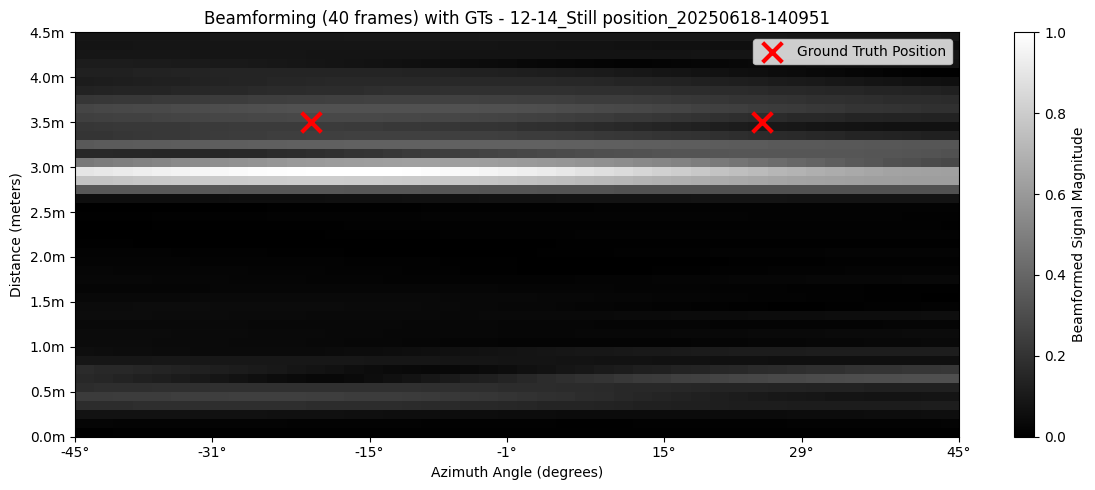


--- Analyzing blobs in time windows (Window size: 40 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.5
Analyzing only the following GT positions: ['12', '14']

--- Blob analysis complete ---
  '12' detected in 5 windows, starting at frames: [30, 420, 450, 460, 510]...
  '14' detected in 1 windows, starting at frames: [1140]...

--- Blob Detection Pipeline Complete ---


In [22]:
# Example of blob detection for a specific file
print("\n--- Running Single File Blob Detection Example ---")
base_file_path_blob_example = "/kaggle/input/haeeai-project-uwb/SR250Mate/12-14_Still position_20250618-140951_sr250_rx0.npy"
detected_blobs_single_file = run_blob_detection_pipeline(
    base_file_path_blob_example,
    stabilization_frames=20
)

### 7.3 Aggregate Blob Detections Across All Files
This function processes all eligible radar files in the dataset, runs the blob detection pipeline, and aggregates the detection counts into a 2D matrix (Ground Truth Label vs. Time Frame Index). This allows for a holistic view of detection performance across the entire dataset.

In [23]:
def aggregate_blob_detections_across_all_files(
    dataset_base_path: str = "/kaggle/input/haeeai-project-uwb/SR250Mate/",
    max_frame_index_for_plot: int = 1200,
    stabilization_frames_agg: int = 20,
    num_angles_agg: int = 31, # For blob analysis (31 angles from -45 to 45 deg)
    detection_threshold_agg: float = detection_threshold,
    window_size_agg: int = WINDOW_SIZE_BLOB_ANALYSIS,
    stride_agg: int = STEP_SIZE_BLOB_ANALYSIS
):
    """
    Processes all SR250Mate files to aggregate blob detection counts across all time frames
    and ground truth positions, then visualizes the results as a heatmap.

    Args:
        dataset_base_path (str): The base directory containing the SR250 radar .npy files.
        max_frame_index_for_plot (int): The maximum frame index to include on the X-axis of the aggregated plot.
        declutter_method_agg (str): Decluttering method to use.
        declutter_param_agg (float): Parameter for the decluttering method.
        stabilization_frames_agg (int): Number of initial frames to remove after decluttering.
        num_angles_agg (int): Number of azimuth angles for beamforming during aggregation.
        detection_threshold_agg (float): Detection threshold for blob analysis during aggregation.
        window_size_agg (int): Window size for blob analysis during aggregation.
        stride_agg (int): Stride for blob analysis during aggregation.
    """
    print("\n--- Starting Aggregated Blob Detection Across All Files ---")

    # Define the nine ground truth labels in a fixed order for the Y-axis
    gt_labels_ordered = ["2", "3", "4", "7", "8", "9", "12", "13", "14"]
    num_gt_labels = len(gt_labels_ordered)

    num_frames_xaxis = max_frame_index_for_plot + 1 # Because it includes 0

    # Initialize the aggregation matrix with zeros
    blob_detection_counts = np.zeros(
        (num_gt_labels, num_frames_xaxis), dtype=int
    )

    # Create a mapping from GT label to its corresponding row index for easy access
    gt_label_to_row_idx = {label: i for i, label in enumerate(gt_labels_ordered)}

    total_num_files_processed = 0
    
    # Generate beam steering angles for aggregation task
    beam_steering_angles_agg = np.deg2rad(np.linspace(min_angle_deg, max_angle_deg, num_angles_agg))

    for dirname, _, filenames in os.walk(dataset_base_path):
        for filename in filenames:
            # We only process 'rx0.npy' files, and skip "(move)" files as in original notebook
            if filename.endswith("_sr250_rx0.npy") and not filename.startswith("(move)"):
                full_path_filename = os.path.join(dirname, filename)
                print(f"\nProcessing file for aggregation: {full_path_filename}")
                
                # 1. Extract labels (GTs for this specific file)
                current_file_gt_labels = extract_scenario_numbers(full_path_filename)
                if not current_file_gt_labels:
                    print(f"  No valid GT labels found for '{os.path.basename(full_path_filename)}'. Skipping.")
                    continue

                # 2. Load and declutter data
                all_complex_data = _get_all_decluttered_complex_data(
                    full_path_filename,
                    stabilization_frames_to_remove=stabilization_frames_agg,
                    display_time_distance_plot=False
                )

                if not all_complex_data:
                    print(f"  Skipping processing of {os.path.basename(full_path_filename)} due to data loading/decluttering failure.")
                    continue 

                antenna1_data = all_complex_data[0]  # RX0
                antenna2_data = all_complex_data[1]  # RX2

                # 3. Perform azimuth beamforming
                beamformed_3d_data = perform_azimuth_beamforming(
                    antenna1_data, antenna2_data, d, k, beam_steering_angles_agg
                )

                if beamformed_3d_data is None:
                    print(f"  Skipping processing of {os.path.basename(full_path_filename)} due to beamforming failure.")
                    continue 
                
                # 4. Perform blob analysis
                current_file_detections = analyze_blobs_in_time_windows(
                    beamformed_3d_data,
                    ground_truth_positions,
                    detection_threshold_agg,
                    window_size_agg,
                    stride_agg,
                    gt_labels_to_analyze=current_file_gt_labels
                )

                # Free up memory
                del beamformed_3d_data
                gc.collect()

                if current_file_detections:
                    total_num_files_processed += 1
                    # 5. Aggregate detections into the matrix
                    for gt_label, detected_frames_list in current_file_detections.items():
                        if gt_label in gt_label_to_row_idx and detected_frames_list:
                            row_idx = gt_label_to_row_idx[gt_label]
                            for frame_idx in detected_frames_list:
                                # Only increment if the frame_idx is within our desired X-axis range
                                if 0 <= frame_idx <= max_frame_index_for_plot:
                                    blob_detection_counts[row_idx, frame_idx] += 1
                                else:
                                    print(f"  Warning: Detected frame {frame_idx} for GT '{gt_label}' is out of the [0, {max_frame_index_for_plot}] range. Skipping count for this frame.")
                else:
                    print(f"  No blob detections returned for {os.path.basename(full_path_filename)}, or analysis failed.")

    print(f"\n--- Finished processing {total_num_files_processed} eligible files for aggregation. ---")
    print(f"Aggregation matrix shape: {blob_detection_counts.shape}")

    # --- Visualization of the aggregated 2D matrix ---
    print("\nGenerating aggregated blob detection heatmap...")

    plt.figure(figsize=(15, 8))
    im = plt.imshow(
        blob_detection_counts,
        aspect='auto',
        origin='lower',  # Keep origin lower so frame 0 is at the bottom of the y-axis
        cmap='viridis',   # Or 'hot', 'magma', 'Greys', etc.
        interpolation='nearest'
    )

    plt.title('Aggregated Blob Detections Across All Files')
    plt.xlabel('Time Frame Index (start of window)')
    plt.ylabel('Ground Truth Position Label')
    plt.colorbar(im, label='Number of Detections')

    # Set X-axis ticks to show meaningful intervals (e.g., every 100 frames)
    x_ticks_interval = 100
    plt.xticks(np.arange(0, num_frames_xaxis, x_ticks_interval))

    # Set Y-axis ticks to show the GT labels
    plt.yticks(np.arange(num_gt_labels), gt_labels_ordered)

    plt.tight_layout()
    plt.show()
    plt.close() # Close the figure to free memory
    print("\n--- Aggregated Blob Detection Complete ---")

#### Run Aggregated Blob Detection


--- Starting Aggregated Blob Detection Across All Files ---

Processing file for aggregation: /kaggle/input/haeeai-project-uwb/SR250Mate/13-14_Still position_20250618-141413_sr250_rx0.npy
Processing antenna files for '13-14_Still position_20250618-141413_sr250_rx0.npy'...
  13-14_Still position_20250618-141413_sr250_rx0.npy processed. Shape after decluttering and frame removal: (1200, 120)
  13-14_Still position_20250618-141413_sr250_rx2.npy processed. Shape after decluttering and frame removal: (1200, 120)
Shape of the antennas data after cropping: (1200, 45), with dtype complex64
Starting beamforming over 1200 time frames and 45 range bins...
Beamforming complete for all frames and range bins.

--- Analyzing blobs in time windows (Window size: 40 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.5
Analyzing only the following GT positions: ['13', '14']

--- Blob analysis complete ---
  '13' detected in 2 windows

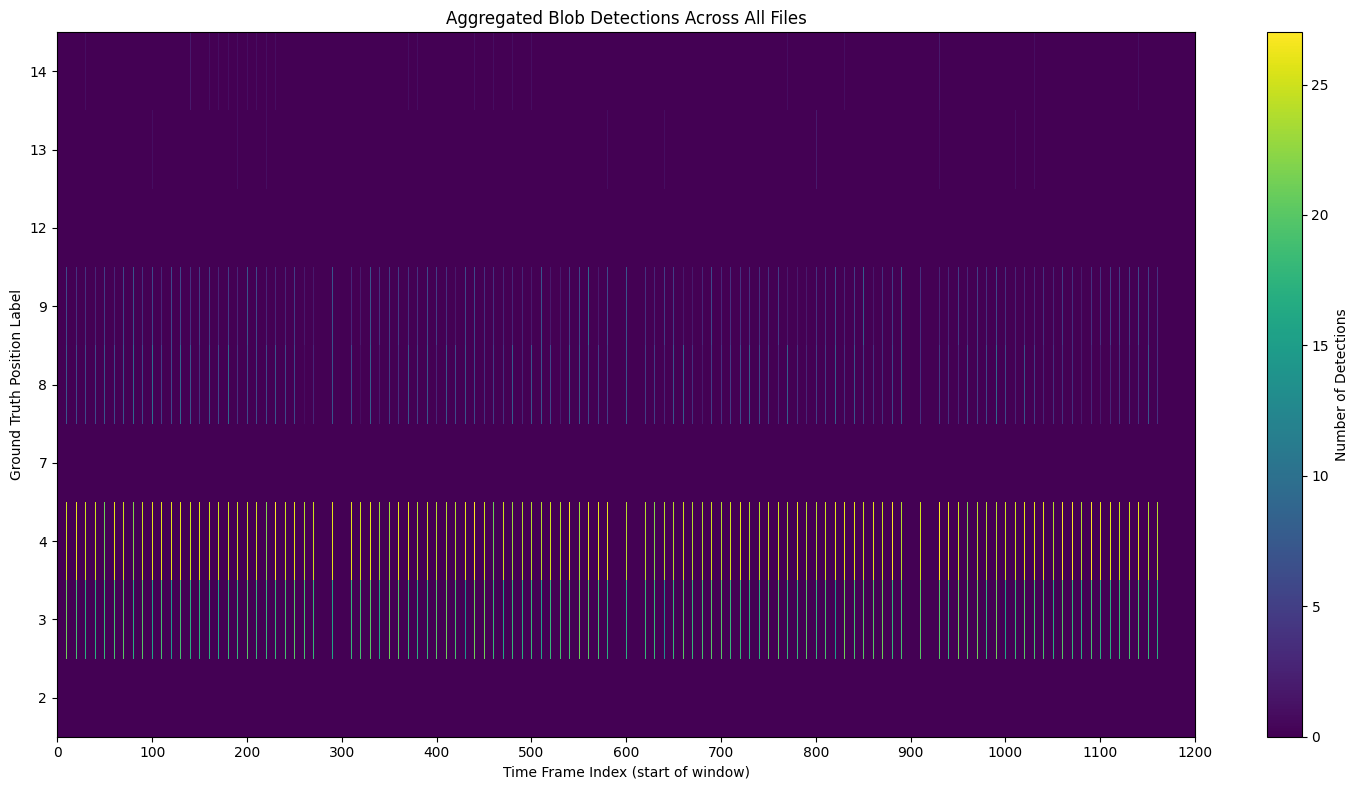


--- Aggregated Blob Detection Complete ---


In [24]:
# Run the aggregated blob detection pipeline across the entire dataset
aggregate_blob_detections_across_all_files(
    dataset_base_path="/kaggle/input/haeeai-project-uwb/SR250Mate/",
    max_frame_index_for_plot=1200, # Max X-axis frame index for the plot
    stabilization_frames_agg=20
)